# House Price Prediction — EDA, Cleaning & Visualization

**Dataset:** [House Price by Juhi Bhojani](https://www.kaggle.com/datasets/juhibhojani/house-price) (Kaggle)

This notebook covers the first stage of the project pipeline:

1. **Load & Inspect** — get a first look at the raw dataset (EDA part 1).
2. **Data Cleaning & Feature Engineering** — the dataset is messy on purpose (text prices,
   text areas, mixed units, high-cardinality categoricals, missing values). We fix all of
   that here.
3. **Visualization** — after cleaning, we produce plots to understand relationships between
   features and the target price.
4. **Export** — save a clean, model-ready CSV (`house_prices_clean.csv`) that will be reused
   by the three modeling notebooks.


In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

# Nicer default plot style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

pd.set_option("display.max_columns", 30)


## 1. Load & Inspect (Initial EDA)

We start by loading the raw CSV and getting a first look: shape, column types,
summary statistics, and the amount of missing data per column.


In [2]:
df = pd.read_csv("data/house_prices.csv")
print("Shape:", df.shape)
df.head()


Shape: (187531, 21)


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,Furnishing,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,Unfurnished,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,Semi-Furnished,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,Unfurnished,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,Unfurnished,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,Unfurnished,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16  Car Parking  

In [4]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Index,187531.0,NaN,NaN,NaN,93765.0,54135.681003,0.0,46882.5,93765.0,140647.5,187530.0
Title,187531,32446,2 BHK Ready to Occupy Flat for sale in Divyasr...,2106,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,184508,65634,Multistorey apartment is available for sale. I...,2732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Amount(in rupees),187531,1561,Call for Price,9684,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price (in rupees),169866.0,NaN,NaN,NaN,7583.771885,27241.705819,0.0,4297.0,6034.0,9450.0,6700000.0
location,187531,81,new-delhi,27599,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Carpet Area,106858,2758,1000 sqft,5285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Status,186916,1,Ready to Move,186916,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Floor,180454,947,2 out of 4,12433,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transaction,187448,4,Resale,144172,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_pct.to_frame(name="missing_%")


,missing_%
Plot Area,100.000000
Dimensions,100.000000
Society,58.485264
Super Area,57.422506
Car Parking,55.114621
overlooking,43.425354
Carpet Area,43.018488
facing,37.451408
Ownership,34.936624
Balcony,26.094352


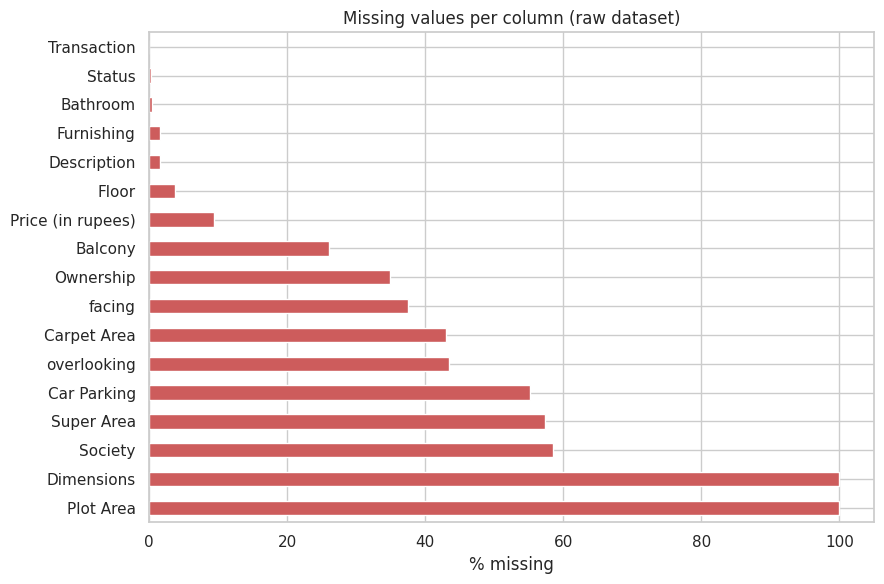

In [6]:
fig, ax = plt.subplots(figsize=(9, 6))
missing_pct[missing_pct > 0].plot(kind="barh", ax=ax, color="indianred")
ax.set_xlabel("% missing")
ax.set_title("Missing values per column (raw dataset)")
plt.tight_layout()
plt.show()


**Observations (initial EDA):**

- The raw dataset has **187,531 rows** and **21 columns**.
- Numeric-looking columns (`Bathroom`, `Balcony`, `Price (in rupees)`) are partly numeric but
  contain missing values; several columns that *should* be numeric (`Amount(in rupees)`,
  `Carpet Area`, `Super Area`, `Floor`, `Car Parking`) are stored as **free text** and need
  parsing.
- `Plot Area` and `Dimensions` are essentially **100% empty** and are not usable.
- `Society`, `Super Area`, `Car Parking`, `overlooking`, `Carpet Area`, `facing`, and
  `Ownership` all have **35%–100% missing values**.
- `Title` and `Description` are free-text columns not directly usable by a regression model
  without NLP techniques, which are out of scope here.

This confirms the guide's warning: the dataset is messy on purpose, and most of our work will
be in the cleaning stage below.


## 2. Data Cleaning & Feature Engineering

We now turn the messy raw columns into a clean, numeric/categorical feature set that a
scikit-learn pipeline can consume. Steps, in order:

1. Parse `Amount(in rupees)` (e.g. `"42 Lac"`, `"1.40 Cr"`, `"Call for Price"`) into a numeric
   `price_clean` column (our regression target). Drop rows with no usable price.
2. Parse `Carpet Area` / `Super Area` (e.g. `"1200 sqft"`, `"140 sqm"`) into a numeric,
   sqft-normalized `carpet_area_sqft` column. Since `Carpet Area` alone is missing for ~43% of
   rows, we **fall back to `Super Area`** (converted to sqft) whenever `Carpet Area` is
   missing, which recovers most of those rows.
3. Parse `Floor` (e.g. `"10 out of 11"`, `"Ground out of 2"`) into a numeric `floor_num`
   (Ground → 0, Basement → -1).
4. Convert `Bathroom`, `Balcony`, `Car Parking` to numeric counts (`Car Parking` values like
   `"2 Covered"` → `2`).
5. Group the high-cardinality `location` column: keep the top-50 most frequent locations and
   bucket everything else into `"other"`.
6. Drop columns that are unusable or would leak the target: `Index`, `Title`, `Description`,
   `Dimensions`, `Plot Area` (near-100% empty / free text), `Society` (too high cardinality,
   too sparse), `Ownership` and `overlooking` (too sparse to impute reliably), and
   `Price (in rupees)` / raw `Amount(in rupees)` / raw `Carpet Area` / `Super Area` / `Floor`
   / `Bathroom` / `Balcony` / `Car Parking` (replaced by their cleaned versions above, or in
   the case of `Price (in rupees)` a near-duplicate of the target that would leak information).
7. Drop rows that still have no usable area.
8. Remove outliers using **price-per-sqft**: drop listings below the 1st percentile or above
   the 99th percentile of price-per-sqft (typos, "Call for price" artifacts, unrealistic
   listings).


In [7]:
def parse_amount(x):
    """Convert a text price like '42 Lac' or '1.40 Cr' into a numeric rupee value."""
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 1e5
        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 1e7
        return float(x.replace(",", ""))
    except ValueError:
        return None  # e.g. "Call for Price"


df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)
print("Rows with unparseable price:", df["price_clean"].isna().sum())

df = df.dropna(subset=["price_clean"])
print("Shape after dropping rows without a usable price:", df.shape)


Rows with unparseable price: 9684
Shape after dropping rows without a usable price: (177847, 22)


In [8]:
def parse_area(x):
    """Extract a numeric area from text like '1200 sqft' or '140 sqm', normalised to sqft."""
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    match = re.search(r"([\d,]+\.?\d*)", x)
    if not match:
        return None
    value = float(match.group(1).replace(",", ""))
    if "sqm" in x or "sq.m" in x or "sq m" in x:
        value = value * 10.764  # 1 sqm ~= 10.764 sqft
    return value


df["carpet_area_sqft"] = df["Carpet Area"].apply(parse_area)
df["super_area_sqft"] = df["Super Area"].apply(parse_area)

# Carpet Area is missing for ~43% of rows -> fall back to Super Area (converted to sqft)
df["carpet_area_sqft"] = df["carpet_area_sqft"].fillna(df["super_area_sqft"])
print("Rows still missing an area value:", df["carpet_area_sqft"].isna().sum())


Rows still missing an area value: 90


In [9]:
def parse_floor(x):
    """Extract the floor number from text like '10 out of 11' or 'Ground out of 2'."""
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    part = x.split("out of")[0].strip()
    if part == "ground":
        return 0
    if "basement" in part:
        return -1
    match = re.search(r"(-?\d+)", part)
    return float(match.group(1)) if match else None


df["floor_num"] = df["Floor"].apply(parse_floor)
df["floor_num"].describe()


count    170898.000000
mean          4.499029
std           4.701323
min          -1.000000
25%           2.000000
50%           3.000000
75%           6.000000
max         200.000000
Name: floor_num, dtype: float64

In [10]:
def parse_count(x):
    """Convert values like '2 Covered', '1 Open', or plain numbers into a numeric count."""
    if pd.isna(x):
        return None
    try:
        return float(x)
    except (ValueError, TypeError):
        match = re.search(r"(\d+)", str(x))
        return float(match.group(1)) if match else None


df["bathroom_num"] = df["Bathroom"].apply(parse_count)
df["balcony_num"] = df["Balcony"].apply(parse_count)
df["car_parking_num"] = df["Car Parking"].apply(parse_count)

# Impute: median for bathroom/balcony (usually present), 0 for car parking (usually means none)
df["bathroom_num"] = df["bathroom_num"].fillna(df["bathroom_num"].median())
df["balcony_num"] = df["balcony_num"].fillna(df["balcony_num"].median())
df["car_parking_num"] = df["car_parking_num"].fillna(0)


In [11]:
# High-cardinality categorical: keep top-50 locations, bucket the rest as "other"
top_locations = df["location"].value_counts().nlargest(50).index
df["location_grouped"] = df["location"].where(df["location"].isin(top_locations), "other")
print("Unique locations after grouping:", df["location_grouped"].nunique())


Unique locations after grouping: 51


In [12]:
# Drop columns we no longer need: unusable/near-empty text columns, replaced raw columns,
# and the leaky "Price (in rupees)" column (a near-duplicate of the target).
drop_cols = [
    "Index", "Title", "Description", "Dimensions", "Plot Area", "Society",
    "Price (in rupees)", "Amount(in rupees)", "Carpet Area", "Super Area",
    "super_area_sqft", "Floor", "Bathroom", "Balcony", "Car Parking",
    "overlooking", "Ownership", "location",
]
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

# Drop rows that still have no usable area
df = df.dropna(subset=["carpet_area_sqft"])
print("Shape after dropping unusable columns/rows:", df.shape)
df.head()


Shape after dropping unusable columns/rows: (177757, 11)


,Status,Transaction,Furnishing,facing,price_clean,carpet_area_sqft,floor_num,bathroom_num,balcony_num,car_parking_num,location_grouped
0,Ready to Move,Resale,Unfurnished,NaN,4200000.0,500.0,10.0,1.0,2.0,0.0,thane
1,Ready to Move,Resale,Semi-Furnished,East,9800000.0,473.0,3.0,2.0,2.0,1.0,thane
2,Ready to Move,Resale,Unfurnished,East,14000000.0,779.0,10.0,2.0,2.0,1.0,thane
3,Ready to Move,Resale,Unfurnished,NaN,2500000.0,530.0,1.0,1.0,1.0,0.0,thane
4,Ready to Move,Resale,Unfurnished,West,16000000.0,635.0,20.0,2.0,2.0,1.0,thane


In [13]:
# Outlier removal using price-per-sqft (catches typos and unrealistic listings)
price_per_sqft = df["price_clean"] / df["carpet_area_sqft"]
low, high = price_per_sqft.quantile([0.01, 0.99])
print(f"Keeping price-per-sqft between {low:,.0f} and {high:,.0f}")

before = df.shape[0]
df = df[(price_per_sqft >= low) & (price_per_sqft <= high)]
print(f"Removed {before - df.shape[0]} outlier rows -> final shape: {df.shape}")


Keeping price-per-sqft between 2,285 and 101,504
Removed 3286 outlier rows -> final shape: (174471, 11)


In [14]:
print("Remaining missing values (will be imputed inside the model pipeline):")
df.isna().mean().sort_values(ascending=False).to_frame("missing_%")


Remaining missing values (will be imputed inside the model pipeline):


,missing_%
facing,0.363785
floor_num,0.039468
Furnishing,0.011652
Status,0.003387
Transaction,0.000378
price_clean,0.000000
carpet_area_sqft,0.000000
bathroom_num,0.000000
balcony_num,0.000000
car_parking_num,0.000000


The dataset is now clean: `price_clean` is a proper numeric target, `carpet_area_sqft`,
`floor_num`, `bathroom_num`, `balcony_num`, and `car_parking_num` are numeric features, and
`location_grouped`, `Status`, `Transaction`, `Furnishing`, and `facing` are low-cardinality
categorical features. Remaining missing values (mostly in `facing` and `floor_num`) are small
enough to be handled by imputers inside the modeling pipeline.


## 3. Visualization

With clean data in hand, we now produce plots to understand the target distribution and its
relationship with key features.


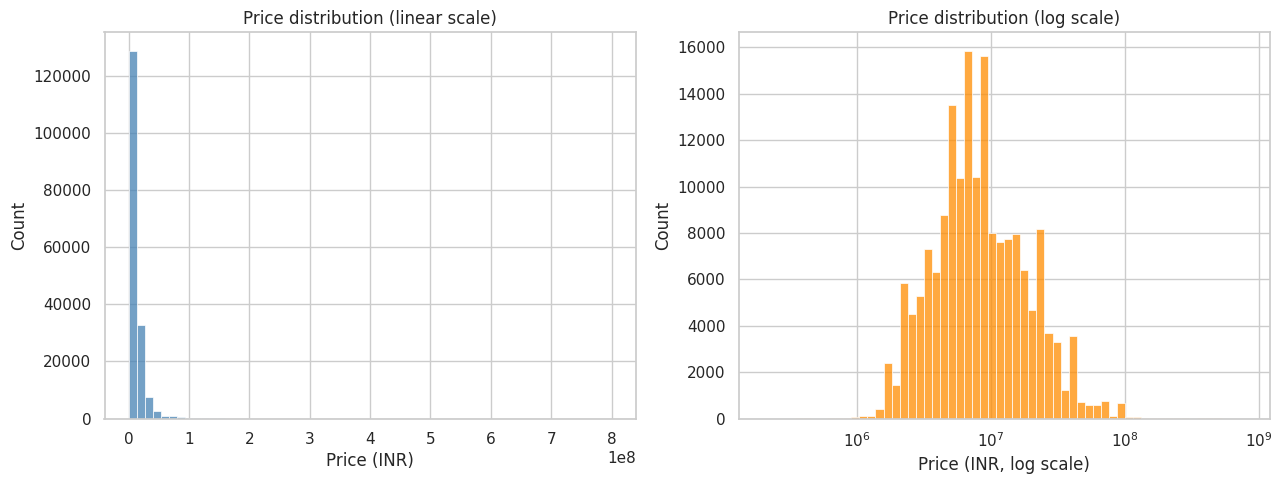

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(df["price_clean"], bins=60, ax=axes[0], color="steelblue")
axes[0].set_title("Price distribution (linear scale)")
axes[0].set_xlabel("Price (INR)")

sns.histplot(df["price_clean"], bins=60, log_scale=True, ax=axes[1], color="darkorange")
axes[1].set_title("Price distribution (log scale)")
axes[1].set_xlabel("Price (INR, log scale)")

plt.tight_layout()
plt.show()


**Comment:** the price distribution is heavily right-skewed — most properties are in the
lower price range with a long tail of very expensive listings. On the log scale the
distribution looks close to log-normal, which is why we tested training on `log1p(price)`
in the modeling notebooks.


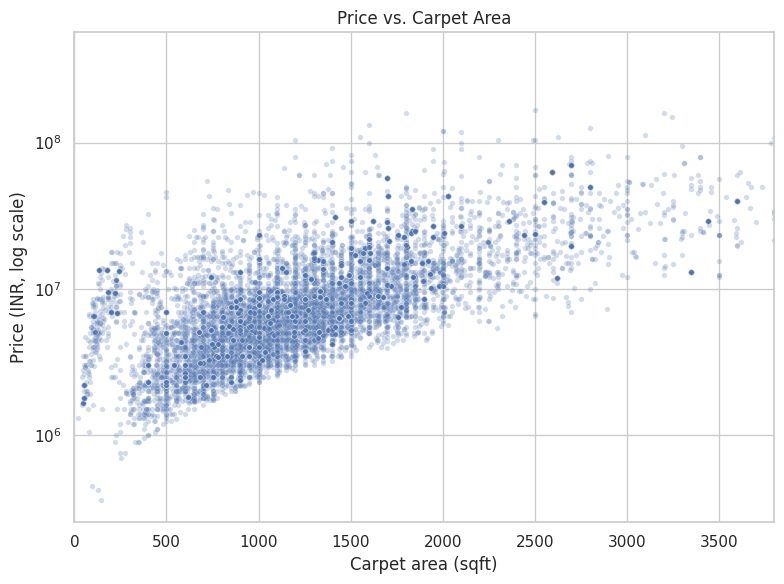

In [16]:
fig, ax = plt.subplots(figsize=(8, 6))
sample = df.sample(min(20000, len(df)), random_state=42)  # sample for a readable scatter plot
sns.scatterplot(data=sample, x="carpet_area_sqft", y="price_clean", alpha=0.25, ax=ax, s=15)
ax.set_yscale("log")
ax.set_xlim(0, sample["carpet_area_sqft"].quantile(0.99))
ax.set_title("Price vs. Carpet Area")
ax.set_xlabel("Carpet area (sqft)")
ax.set_ylabel("Price (INR, log scale)")
plt.tight_layout()
plt.show()


**Comment:** there is a clear positive relationship between area and price, as expected —
larger properties generally cost more. The relationship looks roughly log-linear, which
supports using area (and its interaction with location) as a strong predictive feature.


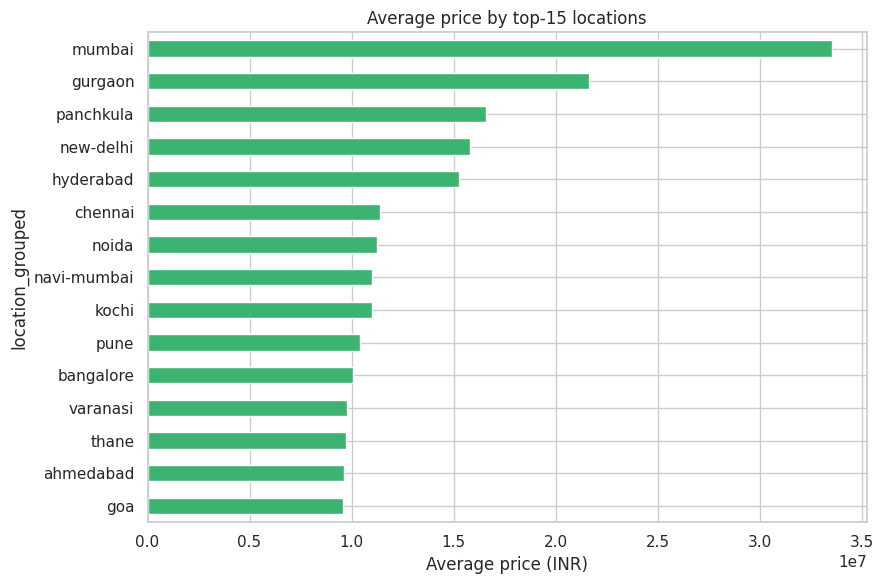

In [17]:
top15 = df.groupby("location_grouped")["price_clean"].mean().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
top15.sort_values().plot(kind="barh", ax=ax, color="mediumseagreen")
ax.set_xlabel("Average price (INR)")
ax.set_title("Average price by top-15 locations")
plt.tight_layout()
plt.show()


**Comment:** average price varies enormously by location (several multiples between the
cheapest and most expensive areas in the top-15), confirming that location is one of the
strongest price drivers and justifying its inclusion as a (grouped) categorical feature.


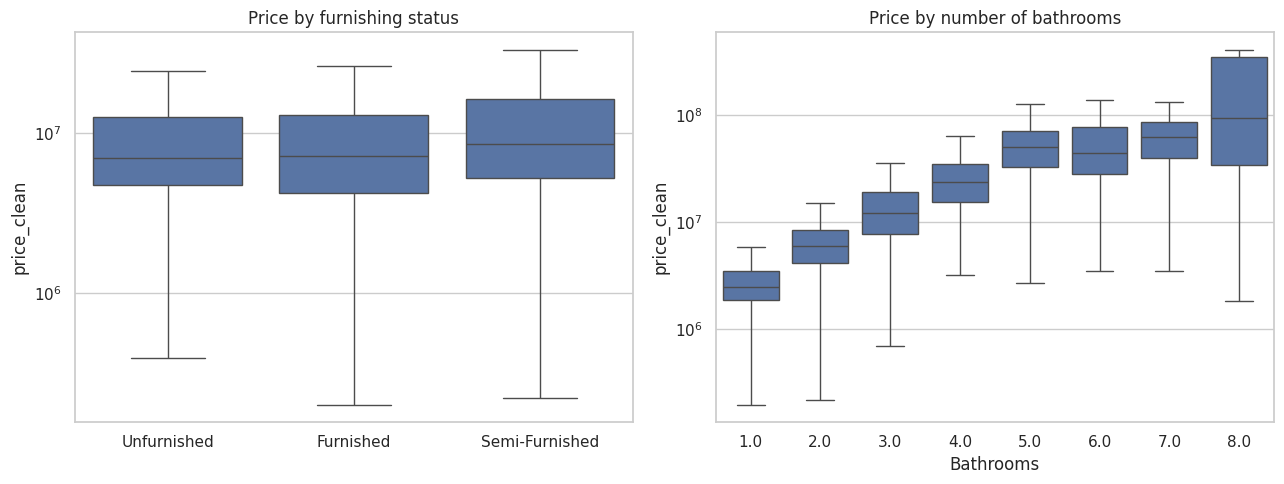

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

order = df.groupby("Furnishing")["price_clean"].median().sort_values().index
sns.boxplot(data=df, x="Furnishing", y="price_clean", order=order, ax=axes[0], showfliers=False)
axes[0].set_yscale("log")
axes[0].set_title("Price by furnishing status")
axes[0].set_xlabel("")

sns.boxplot(data=df, x="bathroom_num", y="price_clean",
            order=sorted(df["bathroom_num"].unique())[:8], ax=axes[1], showfliers=False)
axes[1].set_yscale("log")
axes[1].set_title("Price by number of bathrooms")
axes[1].set_xlabel("Bathrooms")

plt.tight_layout()
plt.show()


**Comment:** fully furnished properties tend to command a higher median price than
semi-furnished or unfurnished ones. Price also increases steadily with the number of
bathrooms, which is intuitive since more bathrooms usually means a larger, more premium
property.


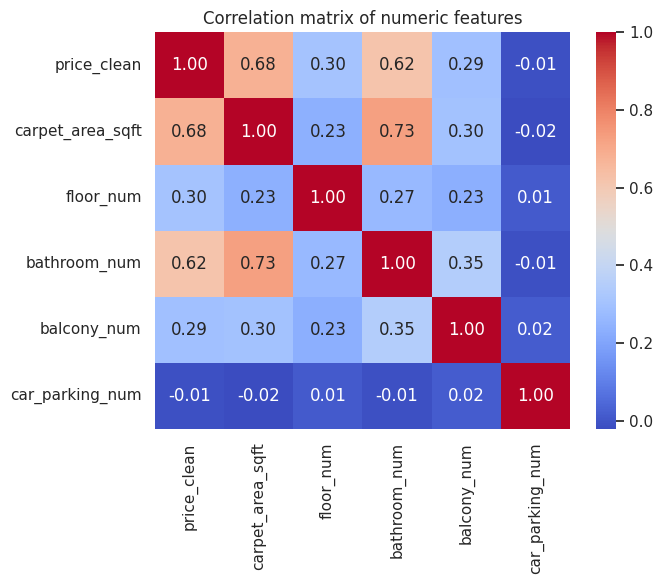

In [19]:
numeric_cols = ["price_clean", "carpet_area_sqft", "floor_num", "bathroom_num",
                "balcony_num", "car_parking_num"]

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Correlation matrix of numeric features")
plt.tight_layout()
plt.show()


**Comment:** `carpet_area_sqft` and `bathroom_num` show the strongest correlation with
`price_clean`, consistent with the scatter/box plots above. `floor_num`, `balcony_num`, and
`car_parking_num` are only weakly correlated with price on their own but may still help the
tree-based models capture non-linear interactions.


## 4. Export the Clean Dataset

Finally, we save the cleaned dataframe as `house_prices_clean.csv` so that the modeling
notebooks (`02_linear_regression.ipynb`, `03_random_forest.ipynb`,
`04_gradient_boosting.ipynb`) can all load the same clean data without repeating the cleaning
logic.


In [20]:
output_path = "data/house_prices_clean.csv"
df.to_csv(output_path, index=False)
print(f"Saved clean dataset with shape {df.shape} to '{output_path}'")
df.head()


Saved clean dataset with shape (174471, 11) to 'data/house_prices_clean.csv'


,Status,Transaction,Furnishing,facing,price_clean,carpet_area_sqft,floor_num,bathroom_num,balcony_num,car_parking_num,location_grouped
0,Ready to Move,Resale,Unfurnished,NaN,4200000.0,500.0,10.0,1.0,2.0,0.0,thane
1,Ready to Move,Resale,Semi-Furnished,East,9800000.0,473.0,3.0,2.0,2.0,1.0,thane
2,Ready to Move,Resale,Unfurnished,East,14000000.0,779.0,10.0,2.0,2.0,1.0,thane
3,Ready to Move,Resale,Unfurnished,NaN,2500000.0,530.0,1.0,1.0,1.0,0.0,thane
4,Ready to Move,Resale,Unfurnished,West,16000000.0,635.0,20.0,2.0,2.0,1.0,thane
